# Research Question 3: Spatial Distribution of Reports in 2025
<div style="background-color:#f0f4f8; padding:15px; border-left:6px solid #2f5597; border-radius:6px;">

## Research Question

Which Zurich Quartiere had the highest reporting intensity of ZüriWieNeu reports per resident in 2025?

## Goal of this notebook

The goal of this notebook is to analyse the spatial distribution of ZüriWieNeu reports across Zurich's Quartiere for the year 2025 as a **normalised rate**, namely the number of reports per 1,000 residents.

While the first two research questions focused on temporal changes and category composition, this notebook adds a spatial perspective. Individual reports are point-based observations, meaning that each report has a specific location. By connecting these point locations to neighborhood polygons, reports can be aggregated to the Quartier level and compared between neighbourhoods.

A first look at the raw counts per Quartier is shown as a reference, but the main result is a **choropleth map of reports per 1,000 residents**. A proper choropleth map shows a *rate* or *share* rather than absolute counts, because counts on a polygon map are strongly driven by how many people live in each polygon. Without normalisation, large or populous Quartiere will almost always appear darker, and the map mostly recovers the underlying population pattern rather than telling us anything about reporting behaviour.

## Why this question is relevant

Comparing reporting activity across neighbourhoods only makes sense once differences in population size are accounted for. A Quartier with 20,000 residents and 1,000 reports is reporting at a very different intensity than a Quartier with 5,000 residents and the same 1,000 reports, even though the absolute counts are identical. The rate of reports per 1,000 residents captures this difference.

However, the rate should still be interpreted carefully. ZüriWieNeu reports are not only generated by residents but also by people who pass through a Quartier — commuters, shoppers, nightlife visitors, tourists. Dividing by residential population therefore tends to **inflate the rate** in central, visitor-heavy Quartiere such as those around Langstrasse, where many reports are generated by non-residents but only residents appear in the denominator. The rate is more informative than raw counts, but it does not fully control for visitor or commuter activity.

## Planned analysis

In this notebook, I will:

1. Load and clean the ZüriWieNeu report data.
2. Filter the reports to the year 2025.
3. Convert the report coordinates into a GeoDataFrame.
4. Load the Zurich Quartiere polygon shapefile.
5. Perform a spatial join between reports and Quartiere.
6. Count the number of reports per Quartier (as a first reference).
7. Load population data per Quartier from Open Data Zürich.
8. Compute reports per 1,000 residents per Quartier.
9. Visualize the result as a choropleth map.
10. Interpret the spatial pattern of reporting intensity.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.loading import load_csv_data
from src.cleaning import clean_reports


In [2]:
quartiere = gpd.read_file(
    "/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/StatQuartiere_ZH"
)

quartiere.head()

/Users/laumagoldmann/miniconda3/envs/sds-env/lib/python3.14/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'StatQuartiere_ZH': 'stzh.adm_statistische_quartiere_v' (default), 'stzh.adm_statistische_quartiere_b_p', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [3]:
quartiere.columns

Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='str')

In [4]:
quartiere.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [5]:
from src.spatial import reports_to_geodataframe

df_raw = load_csv_data("/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/stzh.zwn_meldungen_p.csv")
df_clean = clean_reports(df_raw)

df_2025 = df_clean[df_clean["year"] == 2025].copy()

reports_2025_gdf = reports_to_geodataframe(df_2025)

reports_2025_gdf.head()

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry,year,month,year_month
44670,62831,70201,2025-06-16 20:06:53,2025-06-17 07:07:04,2025-06-17 07:07:04,2682447,1247655,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Veloschrott,https://www.zueriwieneu.ch/photo/70201.0.jpeg?...,desktop,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Veloschrott: Veloschrott,https://www.zueriwieneu.ch/report/70201,POINT (2682447 1247655),2025,6,2025-06-01
45845,61418,68672,2025-05-12 10:05:31,2025-05-12 10:12:05,2025-05-12 10:12:05,2681227,1248047,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Demoliertes Velo,https://www.zueriwieneu.ch/photo/68672.0.jpeg?...,Android,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Demoliertes: Demoliertes Velo,https://www.zueriwieneu.ch/report/68672,POINT (2681227 1248047),2025,5,2025-05-01
45867,61844,69139,2025-05-22 19:41:18,2025-05-22 19:42:05,2025-05-26 05:42:43,2682870,1247836,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,...,Lampe kaputt,NaN,iOS,Besten Dank für Ihre Meldung auf «Züri wie neu...,Lampe kaput: Lampe kaputt,https://www.zueriwieneu.ch/report/69139,POINT (2682870 1247836),2025,5,2025-05-01
45975,63320,70728,2025-06-29 18:24:09,2025-06-30 12:12:04,2025-06-30 12:12:04,2681519,1247334,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Ausgeschlachteter Scooter,https://www.zueriwieneu.ch/photo/70728.0.jpeg?...,iOS,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Ausgeschlac: Ausgeschlachteter Scooter,https://www.zueriwieneu.ch/report/70728,POINT (2681519 1247334),2025,6,2025-06-01
46705,58911,65900,2025-02-16 22:19:45,2025-03-31 09:57:05,2025-04-03 10:26:13,2683763,1247000,Graffiti,Graffiti,fixed - council,...,Graffiti,NaN,Android,Besten Dank für Ihre Meldung auf «Züri wie neu...,Graffiti: Graffiti,https://www.zueriwieneu.ch/report/65900,POINT (2683763 1247000),2025,2,2025-02-01


In [6]:
reports_2025_gdf.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [7]:
import importlib
import src.spatial

importlib.reload(src.spatial)

from src.spatial import reports_to_geodataframe, join_reports_to_quartiere

reports_2025_gdf = reports_to_geodataframe(df_2025)

reports_2025_joined = join_reports_to_quartiere(
    reports_2025_gdf,
    quartiere
)

reports_2025_joined[["service_request_id", "qname", "qnr", "kname", "knr"]].head()

,service_request_id,qname,qnr,kname,knr
44670,70201,Langstrasse,42,Kreis 4,4
45845,68672,Hard,44,Kreis 4,4
45867,69139,City,14,Kreis 1,1
45975,70728,Sihlfeld,34,Kreis 3,3
46705,65900,Hochschulen,12,Kreis 1,1


In [8]:
reports_2025_joined["qname"].isna().sum()

np.int64(0)

The spatial join successfully assigned all 2025 reports to a Zurich Quartier. No reports had missing Quartier information after the join.

In [9]:
reports_by_quartier = (
    reports_2025_joined
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

reports_by_quartier.head(10)


,qname,report_count
16,Langstrasse,1200
27,Sihlfeld,795
3,Altstetten,628
31,Wipkingen,528
28,Unterstrass,517
10,Hard,470
25,Seebach,464
2,Alt-Wiedikon,456
21,Oerlikon,453
15,Höngg,417


## A first look: report counts per Quartier

The table above shows the ten Zurich Quartiere with the highest absolute number of ZüriWieNeu reports in 2025. This is useful as a starting point, but absolute counts do not yet form a proper choropleth: large differences in population size between Quartiere make a count-based comparison hard to interpret. A Quartier with many reports may simply have many residents, rather than a higher reporting intensity.

To address this, the next step loads population data per Quartier from Open Data Zürich and computes the rate of reports per 1,000 residents. This rate is then mapped as the actual choropleth.


## Loading and preparing the population data

The population dataset comes from Open Data Zürich, *Bevölkerung nach Stadtquartier* (`BEV324OD3240.csv`). It contains the economically resident population (`AnzBestWir`) per Statistical Quartier (`QuarLang`) and year (`StichtagDatJahr`) from 1941 to 2025.

For the rate calculation, the data is filtered to 2025 and matched to the Quartier names used in the spatial dataset.

In [10]:
pop = pd.read_csv(
    "/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/BEV324OD3240.csv"
)

pop.head()

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir
0,2025,11,Rathaus,3252
1,2024,11,Rathaus,3260
2,2023,11,Rathaus,3343
3,2022,11,Rathaus,3330
4,2021,11,Rathaus,3275


In [11]:
pop_2025 = pop[pop["StichtagDatJahr"] == 2025].copy()

pop_per_quartier = (
    pop_2025
    .groupby("QuarLang")["AnzBestWir"]
    .sum()
    .reset_index()
    .rename(columns={"QuarLang": "qname", "AnzBestWir": "population"})
)

pop_per_quartier.sort_values("population", ascending=False).head(10)

,qname,population
3,Altstetten,36874
25,Seebach,29320
0,Affoltern,27439
28,Unterstrass,25576
15,Höngg,24981
1,Albisrieden,24304
21,Oerlikon,24205
33,Wollishofen,22029
27,Sihlfeld,21478
2,Alt-Wiedikon,18904


## Computing reports per 1,000 residents

The Quartier polygons, the report counts, and the population data are merged into a single GeoDataFrame. The rate of reports per 1,000 residents is then computed for each Quartier:

$$\text{reports per 1,000 residents} = \frac{\text{report\_count}}{\text{population}} \times 1000$$

Quartiere with no population information (if any) will appear as missing in the merge and are shown in grey on the choropleth.

In [12]:
quartiere_rates = (
    quartiere
    .merge(reports_by_quartier, on="qname", how="left")
    .merge(pop_per_quartier, on="qname", how="left")
)

quartiere_rates["report_count"] = quartiere_rates["report_count"].fillna(0)

quartiere_rates["reports_per_1000"] = (
    quartiere_rates["report_count"] / quartiere_rates["population"] * 1000
)

quartiere_rates[
    ["qname", "report_count", "population", "reports_per_1000"]
].sort_values("reports_per_1000", ascending=False).head(10)

,qname,report_count,population,reports_per_1000
15,City,288,769,374.512354
30,Hochschulen,243,688,353.197674
24,Lindenhof,207,1038,199.421965
2,Langstrasse,1200,11978,100.183670
13,Rathaus,230,3252,70.725707
27,Werd,267,4585,58.233370
6,Seefeld,221,5798,38.116592
26,Gewerbeschule,353,9528,37.048699
17,Sihlfeld,795,21478,37.014620
29,Hard,470,12817,36.670048


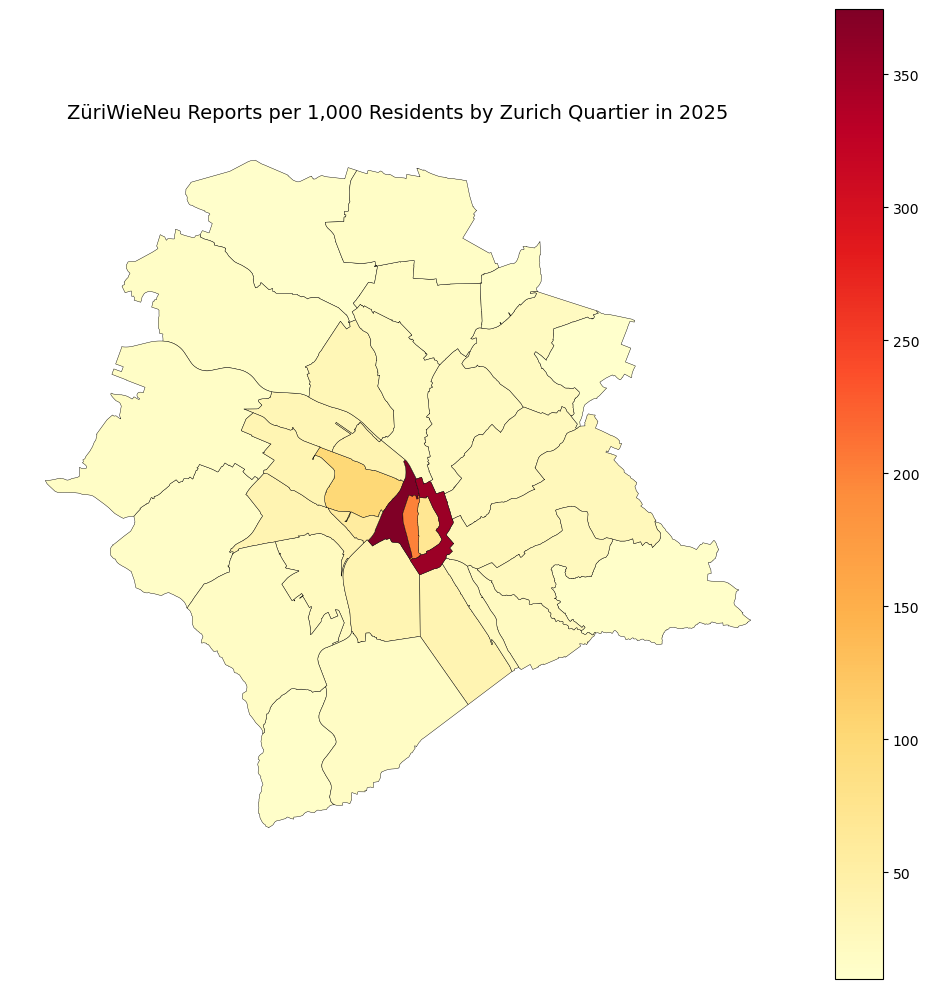

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

quartiere_rates.plot(
    column="reports_per_1000",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    cmap="YlOrRd",
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
)

ax.set_title(
    "ZüriWieNeu Reports per 1,000 Residents by Zurich Quartier in 2025",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.savefig(
    "/Users/laumagoldmann/Desktop/SDS210_IndividualProject/outputs/R3_Choropleth_ReportsPer1000.png",
    bbox_inches="tight"
)
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of the choropleth map

The choropleth map shows the rate of ZüriWieNeu reports per 1,000 residents across Zurich's Quartiere in 2025. Unlike a map of raw counts, this rate accounts for differences in population size and therefore measures **reporting intensity** rather than total reporting volume.

The map shows clear differences in reporting intensity between Quartiere. The highest rates concentrate in **central Quartiere** of the city, while peripheral and residential Quartiere generally show lower rates. The exact ranking differs from the count-based view: some Quartiere that ranked high in absolute counts have large populations and therefore appear less intense on a per-capita basis, while smaller Quartiere with many reports stand out more strongly.

The pattern should be interpreted with two important caveats. First, ZüriWieNeu reports are not only generated by residents. Many reports come from people passing through a Quartier — commuters, shoppers, nightlife visitors, tourists. Because only residents appear in the denominator, this **inflates the rate in central, visitor-heavy Quartiere**, where the reporter population is much larger than the residential population. Second, even after normalisation, the map still reflects *reporting* activity rather than actual infrastructure quality. Differences in residents' willingness to use the platform, the density of infrastructure that can be reported on, and the presence of collection points or nightlife also shape the observed pattern.

Therefore, the map should be read as a measure of **per-capita reporting intensity**, useful for comparing Quartiere on a more equal footing than absolute counts, but not as a direct measurement of either infrastructure condition or resident behaviour alone.

<div style="background-color:#eef9f0; padding:15px; border-left:6px solid #3c9d5d; border-radius:6px;">

## Conclusion

This notebook analysed the spatial distribution of ZüriWieNeu reports across Zurich's Quartiere in 2025, using a normalised rate of reports per 1,000 residents rather than absolute report counts.

Using the report coordinates, each ZüriWieNeu report was converted into a point geometry and spatially joined to the Zurich Quartier polygons. The spatial join was successful for all 2025 reports, meaning that every report could be assigned to a Quartier. Population data per Quartier for 2025 was then obtained from Open Data Zürich (*Bevölkerung nach Stadtquartier*) and used to compute the rate of reports per 1,000 residents.

The normalised choropleth map showed that reporting intensity was unevenly distributed across the city, with the strongest concentrations in central Quartiere and lower rates in residential and peripheral areas. The ranking of Quartiere by per-capita reporting intensity differs from the ranking by absolute counts: populous Quartiere that produced many reports in absolute terms can show only moderate per-capita rates, while smaller central Quartiere stand out more clearly once population is taken into account.

These results should still be interpreted carefully. The rate measures reports per *resident*, but many ZüriWieNeu reports are submitted by non-residents passing through a Quartier. This tends to inflate the rate in central, visitor-heavy areas. The map is therefore best understood as a measure of **per-capita reporting intensity**, which provides a more comparable view across Quartiere than raw counts, but not as a direct measurement of urban infrastructure quality.